## HateXplain - 7 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual
* **Target 4:** Hate speech against indigenous
* **Target 5:** Hate speech against african
* **Target 6:** Hate speech against asian
* **Target 7:** Hate speech against jewish

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:
task_config = {
    "General": {"type": "hate_speech"},
    "Women": {"type": "group_hate", "group": "Women"},
    "Homosexual": {"type": "group_hate", "group": "Homosexual"},
    "Indigenous": {"type": "group_hate", "group": "Indigenous"},
    "African": {"type": "group_hate", "group": "African"},
    "Asian": {"type": "group_hate", "group": "Asian"},
    "Jewish": {"type": "group_hate", "group": "Jewish"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [02:05<00:00,  3.82it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

18:15:24 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
18:15:24 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:06<00:00, 34.72it/s]


Epoch 1 - Average loss: 0.7345


Epoch 2/3: 100%|██████████| 241/241 [00:07<00:00, 32.97it/s]


Epoch 2 - Average loss: 0.7170


Epoch 3/3: 100%|██████████| 241/241 [00:07<00:00, 34.05it/s]


...

Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 88.34it/s]


Epoch 3 - Average loss: 0.6121


19:12:51 | DEBUG | machinemoo | New solution added [0.58924859 0.35140597 0.26686485 0.02221854 0.35389645 0.10589763
 0.27216385]


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


19:12:53 | DEBUG | machinemoo | Calculated weights: [9.99983653e-01 1.47809615e-06 0.00000000e+00 3.96376610e-06
 6.00421125e-07 9.52720356e-06 0.00000000e+00]
19:12:53 | DEBUG | machinemoo | Importance: 9.515032587392724e-07
19:12:53 | DEBUG | machinemoo | Global lower bound (y*): [0.5887297  0.35101221 0.26624161 0.02200873 0.35345869 0.10589712
 0.27216385]
19:12:53 | DEBUG | machinemoo | Iteration 150
19:12:53 | DEBUG | machinemoo | Solutions list: [array([0.58924859, 0.35140597, 0.26686485, 0.02221854, 0.35389645,
       0.10589763, 0.27216385]), array([0.58891369, 0.35189286, 0.26675155, 0.02221783, 0.35464707,
       0.10590064, 0.27253364]), array([0.58913076, 0.35164216, 0.26691047, 0.02221961, 0.35437376,
       0.10589865, 0.27243307]), array([0.58901709, 0.35203957, 0.26735071, 0.02222302, 0.35407734,
       0.10589712, 0.27218685]), array([0.58898323, 0.35153639, 0.26687171, 0.02222296, 0.35394014,
       0.10693734, 0.2725881 ]), array([0.58888761, 0.35256847, 0.26730115,

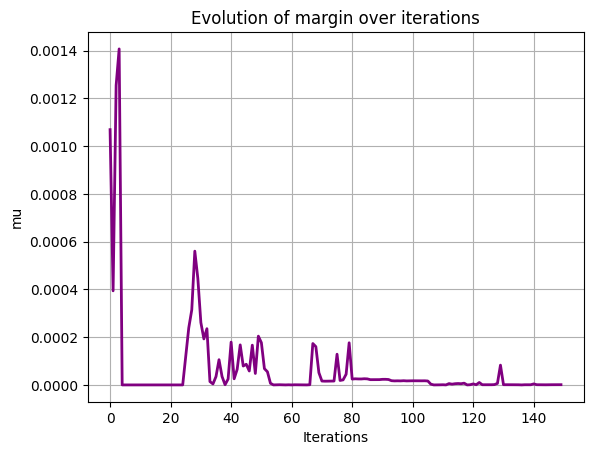

19:12:53 | INFO | machinemoo | Fit runtime: 3448.66 seconds


In [9]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

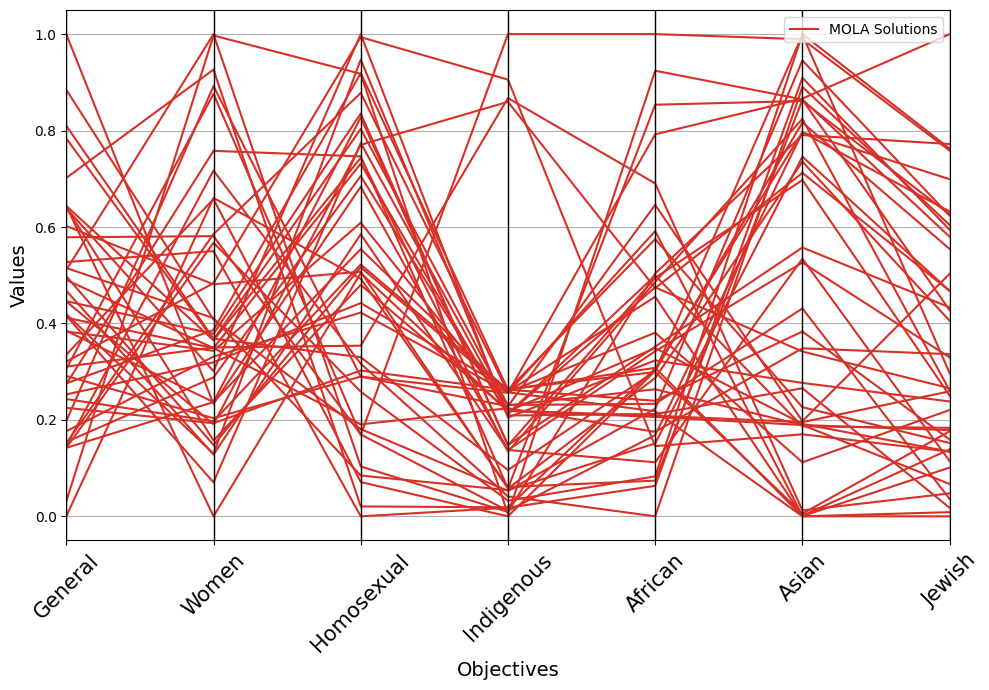

In [10]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            save_path='images/many_objs_mola.pdf'
            )

19:12:53 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
19:12:53 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 84.50it/s]


Epoch 1 - Average loss: 0.7654


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 86.98it/s]


Epoch 2 - Average loss: 0.7455


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 88.57it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:03<00:00, 79.20it/s]


Epoch 2 - Average loss: 0.2761


Epoch 3/3: 100%|██████████| 241/241 [00:03<00:00, 76.34it/s]


Epoch 3 - Average loss: 0.2756


19:53:12 | DEBUG | machinemoo | New solution dominated [0.59643091 0.38788843 0.26559369 0.1822606  0.45262142 0.14300077
 0.29174682]
19:53:12 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ 0.14024544  0.11624251 -0.37005204 -0.40888258 -0.18143173  0.01199307
  0.03762847]
19:53:12 | DEBUG | machinemoo | Calculated weights: [0. 0. 1. 0. 0. 0. 0.]
19:53:12 | DEBUG | machinemoo | Importance: 0.6351664394325736
19:53:12 | DEBUG | machinemoo | Global lower bound (y*): [ 0.14024544  0.11624251 -0.37005204 -0.40888258 -0.18143173  0.01199307
  0.03762847]
19:53:12 | DEBUG | machinemoo | Iteration 150
19:53:12 | DEBUG | machinemoo | Solutions list: [array([0.59645575, 0.38738826, 0.26516702, 0.18198197, 0.45307962,
       0.14331176, 0.29163511]), array([0.59644436, 0.38736689, 0.2658584 , 0.18178686, 0.45240546,
       0.14315958, 0.29146662]), array([0.59633961, 0.38765762, 0.26559198, 0.1817259 , 0.45213204,
       0.14277857, 0.2911475 ]), array([0.59645477, 0.38754281

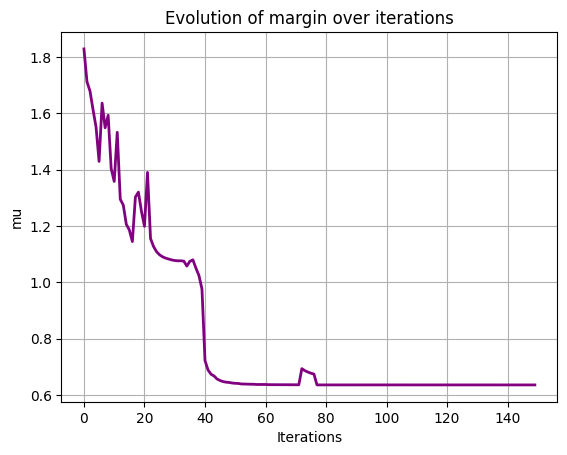

19:53:12 | INFO | machinemoo | Fit runtime: 2419.16 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

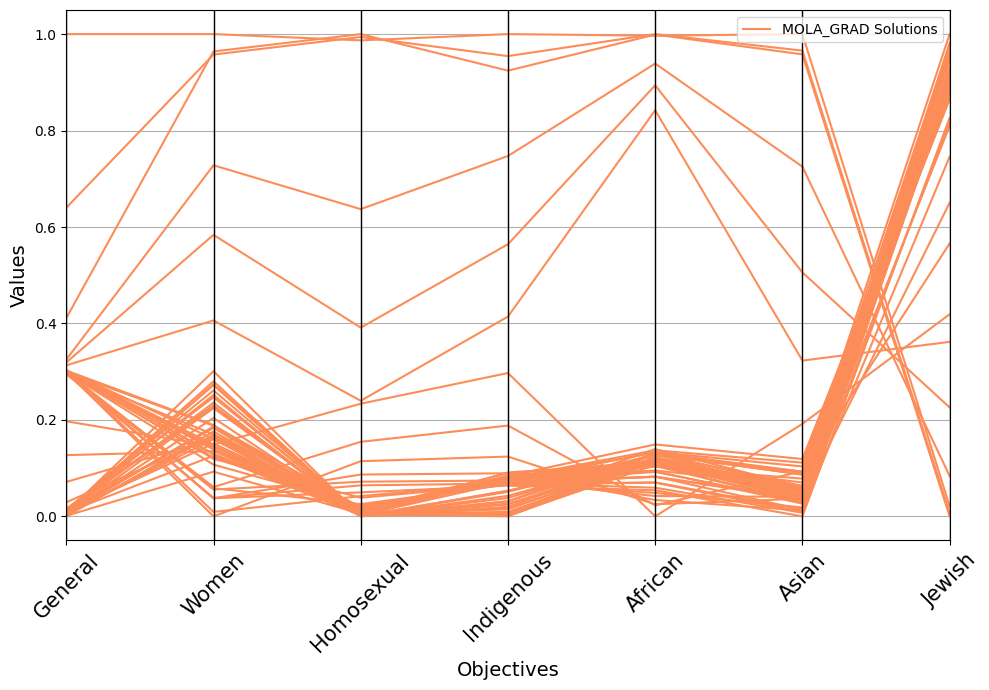

In [12]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            color=['#fc8d59'],
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            save_path='images/many_objs_mola_grad.pdf'
            )

### Random Weight

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

19:53:13 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeGap', 'nodeTimeLimit', 'targetGap'}
19:53:13 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
19:53:13 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/3:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 84.37it/s]


Epoch 1 - Average loss: 0.6973


Epoch 2/3: 100%|██████████| 241/241 [00:03<00:00, 79.05it/s]


Epoch 2 - Average loss: 0.6870


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 96.63it/s]


Epoch 2 - Average loss: 0.2581


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 96.40it/s]


Epoch 3 - Average loss: 0.2566


20:22:04 | DEBUG | machinemoo | 150th solution


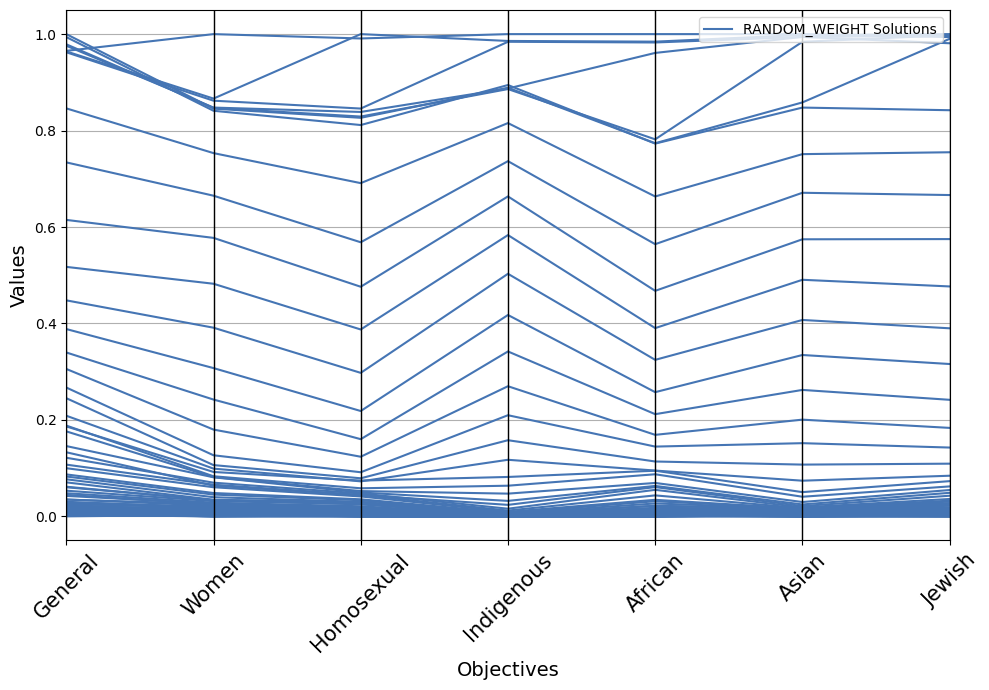

In [14]:
plot_pareto(methods={'random_weight': objs},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            color=['#4575b4'],
            save_path='images/7_objs_rw.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

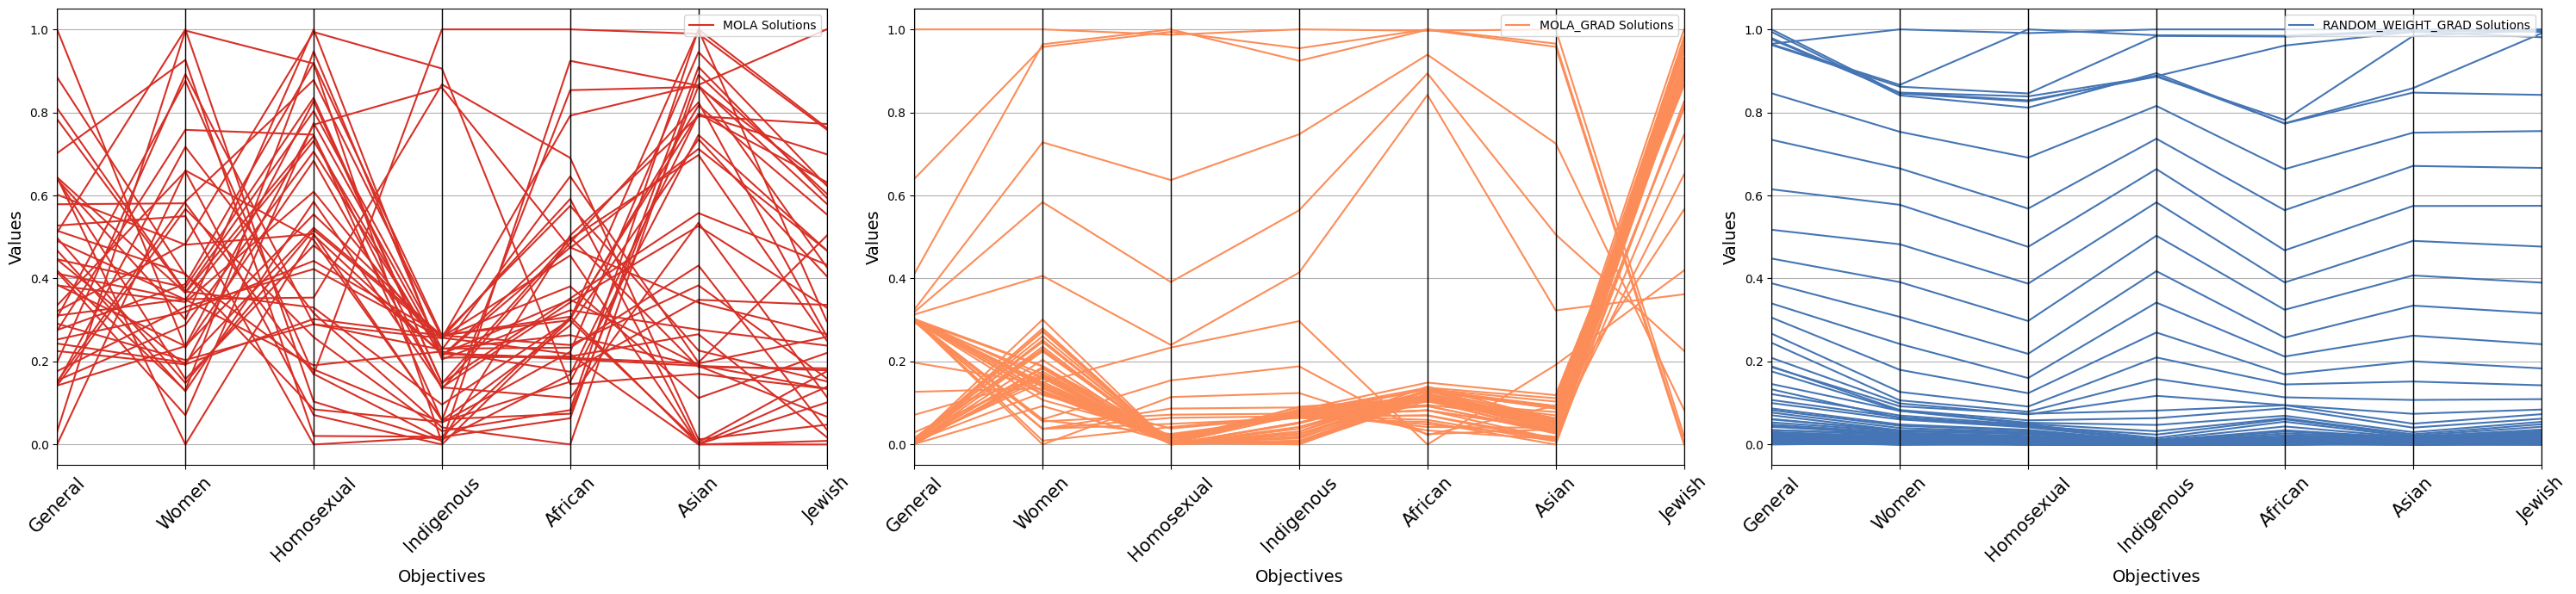

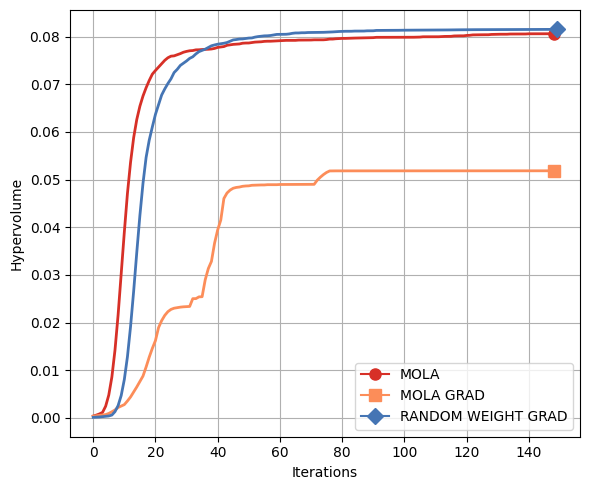

<Figure size 640x480 with 0 Axes>

In [15]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            save_path='images/many_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path='images/many_objs_hypervolume.pdf')

In [ ]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

mola: 43
mola_grad: 55
Número de soluções não-dominadas (RW): 34
[[0.00000000e+00 2.96594057e-03 4.57283838e-03 6.44165470e-04
  2.36806773e-03 4.32021890e-03 1.66070506e-03]
 [2.45739102e-03 3.34187488e-03 8.58507094e-04 5.52392118e-04
  2.22281524e-03 3.86691235e-03 8.35756748e-04]
 [3.15331216e-03 1.56374263e-03 3.22760153e-03 4.80937121e-04
  0.00000000e+00 2.38873832e-03 1.15578305e-03]
 [5.50687595e-03 5.84904079e-05 1.15830588e-03 5.06628967e-04
  1.17739642e-03 2.83082635e-03 8.54114021e-04]
 [5.66891302e-03 2.47094657e-03 3.20917379e-03 3.83154172e-04
  1.24337367e-04 2.04173693e-03 1.13384686e-03]
 [2.91921963e-03 1.57248792e-03 2.55264734e-03 3.66596854e-04
  9.19525888e-05 2.15600311e-03 1.24392450e-03]
 [6.07936540e-03 2.75987073e-03 3.42281188e-04 3.69441387e-04
  2.33844837e-05 2.46659333e-03 2.04937345e-03]
 [4.21136577e-03 0.00000000e+00 2.08735052e-03 3.40259764e-04
  2.85525019e-03 1.08573850e-03 1.25898512e-03]
 [7.66107719e-03 7.19892350e-04 6.97019565e-04 2.651809